In [1]:
import pyclara
import pandas
import matplotlib.pyplot as plt
import sdds
import numpy as np

initializing ocelot...

RF-Track, version 2.5.5

Copyright (C) 2016-2025 CERN, Geneva, Switzerland. All rights reserved.

Author and contact:
 Andrea Latina <andrea.latina@cern.ch>
 BE-ABP Group
 CERN
 CH-1211 GENEVA 23
 SWITZERLAND

This software is distributed under a CERN proprietary software
license in the hope that it will be useful, but WITHOUT ANY WARRANTY;
not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

See the COPYRIGHT and LICENSE files at the top-level directory of
the RF-Track download area: https://gitlab.cern.ch/rf-track

RF-Track was compiled with GSL-2.8 and fftw-3.3.10



[RF-Track] Could not check for updates.


In [2]:
ix = pyclara.Converters.elegant2impactx("../Run/FEBE.lte",
                                        start_element="CLA-FEA-MAG-QUAD-13",
                                        end_element="CLA-FED-SIM-DUMP-01-START",
                                        elegant_twi="../Run/FEBE.twi")

element type  LINE  not recognised, skipping
Initializing AMReX (26.01)...
OMP initialized with 12 OMP threads
AMReX (26.01) initialized

Grids Summary:
  Level 0   1 grids  512 cells  100 % of domain

 Diagnostics: 1
 Space Charge effects: False
 CSR effects: 0
 ISR effects: 0
 Spin tracking: 0

++++ Starting step=1 slice_step=0

**** WARNINGS ******************************************************************
* GLOBAL warning list  after  [ FIRST STEP ]
*
* No recorded warnings.
********************************************************************************


++++ Starting step=2 slice_step=0

++++ Starting step=3 slice_step=0

++++ Starting step=4 slice_step=0

++++ Starting step=5 slice_step=0

++++ Starting step=6 slice_step=0

++++ Starting step=7 slice_step=0

++++ Starting step=8 slice_step=0

++++ Starting step=9 slice_step=0

++++ Starting step=10 slice_step=0

++++ Starting step=11 slice_step=0

++++ Starting step=12 slice_step=0

++++ Starting step=13 slice_step=0

++++ Sta

In [3]:
df = pandas.read_csv("diags/reduced_beam_characteristics.0.0",
                     sep=r"\s+",
                     comment="#")

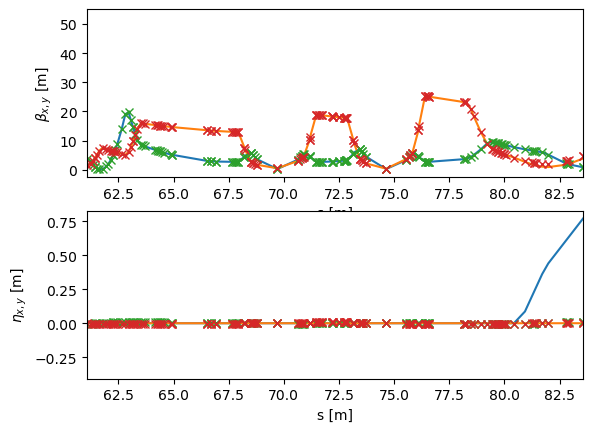

In [4]:
elegant_twi = sdds.load("../Run/FEBE.twi")

e_names = np.array(elegant_twi.getColumnValueList("ElementName"))
e_s = np.array(elegant_twi.getColumnValueList("s"))
e_betax = np.array(elegant_twi.getColumnValueList("betax"))
e_betay = np.array(elegant_twi.getColumnValueList("betay"))
e_etax = np.array(elegant_twi.getColumnValueList("etax"))
e_etay = np.array(elegant_twi.getColumnValueList("etay"))

e_idx0 = np.where(e_names == "CLA-FEA-MAG-QUAD-13")[0]-1 # TODO not sure about this offset 
e_idxN = np.where(e_names == "CLA-FED-SIM-DUMP-01-START")[0]
elegant_twi.getColumnValueList("ElementName")

plt.subplot(2,1,1)
plt.plot(e_s, e_betax)
plt.plot(e_s, e_betay)
plt.plot(df['s'] + e_s[e_idx0],df['beta_x'],"x")
plt.plot(df['s'] + e_s[e_idx0],df['beta_y'],"x")
plt.xlabel("s [m]")
plt.ylabel("$\\beta_{x,y}$ [m]");
plt.xlim(e_s[e_idx0], e_s[e_idxN]);

plt.subplot(2,1,2)
plt.plot(e_s, e_etax)
plt.plot(e_s, e_etay)
plt.plot(df['s'] + e_s[e_idx0],df['dispersion_x'],"x")
plt.plot(df['s'] + e_s[e_idx0],df['dispersion_y'],"x")
plt.xlabel("s [m]")
plt.ylabel("$\\eta_{x,y}$ [m]");
plt.xlim(e_s[e_idx0], e_s[e_idxN]);


In [8]:
for e in ix['impactx_sim'].lattice :
    print(e)

<impactx.elements.ExactQuad, name=CLA-FEA-MAG-QUAD-13, ds=0.150000, k=18.413533, unit=0>
<impactx.elements.Drift, name=FEBE_DRIFT_155, ds=0.100000>
<impactx.elements.Drift, name=CLA-FEA-DIA-BPM-07-DRIFT-01, ds=0.100000>
<impactx.elements.Marker, name=CLA-FEA-DIA-BPM-07>
<impactx.elements.Drift, name=CLA-FEA-DIA-BPM-07-DRIFT-02, ds=0.100000>
<impactx.elements.Drift, name=FEBE_DRIFT_156, ds=0.100000>
<impactx.elements.ExactQuad, name=CLA-FEA-MAG-QUAD-14, ds=0.150000, k=-8.422733, unit=0>
<impactx.elements.Drift, name=FEBE_DRIFT_157, ds=0.164521>
<impactx.elements.Drift, name=CLA-FEA-DIA-ICT-01, ds=0.100000>
<impactx.elements.Drift, name=FEBE_DRIFT_158, ds=0.108709>
<impactx.elements.Drift, name=CLA-FEA-DIA-SCR-04-DRIFT-01, ds=0.100000>
<impactx.elements.Marker, name=CLA-FEA-DIA-SCR-04>
<impactx.elements.Drift, name=CLA-FEA-DIA-SCR-04-DRIFT-02, ds=0.100000>
<impactx.elements.Drift, name=FEBE_DRIFT_159, ds=0.089270>
<impactx.elements.Drift, name=CLA-FEA-MAG-HVCOR-04, ds=0.200000>
<impactx.